<a href="https://colab.research.google.com/github/marrodcab12/marrodcab12/blob/main/AINE_2026_TXT_1_Procesamiento_del_Lenguaje_Natural_marrodcab12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Información No Estructurada**

## Máster en Ingeniería del Software: Cloud, Datos y Gestión TI

### Curso 2025-26

---
---



**Escriba aquí su nombre y apellidos:** MARIA LUISA RODRIGUEZ CABRERA

> Añadir blockquote



Debes entregar este notebook con todo el trabajo que puedas completar antes de la fecha límite:
* Completar los ejercicios entregables (titulados "☞ Ejercicio entregable")

**Antes de entregar, rellena con tu nombre y apellidos la celda anterior, y cambia el nombre del notebook antes de entregarlo, sustituyendo la palabra "uvus" por tu usuario de la US).**



---



---



# TEXTOS 1: **Procesamiento del Lenguaje Natural**
Última modificación: febrero de 2026

La siguiente celda contiene una serie de dependencias que vamos a utilizar en este notebook. También se descargan algunos recursos que utilizaremos a lo largo del notebook.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import math
import spacy
from spacy.symbols import ADJ, PROPN, NOUN, VERB, AUX
from spacy.matcher import Matcher
import spacy.cli
import numpy as np
import textwrap
from sklearn.model_selection import train_test_split
import requests
import shutil
import os
from tqdm.auto import tqdm
from wordcloud import WordCloud

datos_basedir = "./datos/"

def download_file(url, basedir):
  with requests.get(url, stream=True) as r:
      if not os.path.isdir(basedir):
        os.makedirs(basedir)
      total_length = int(r.headers.get("Content-Length"))
      filename = url.split("/")[-1].split("?")[0]
      with tqdm.wrapattr(r.raw, "read", total=total_length, desc=filename) as raw:
          with open(basedir + filename, 'wb') as output:
              shutil.copyfileobj(raw, output)

download_file('https://www.dropbox.com/s/a2xzik0vyymvykw/prensa.csv?dl=1', datos_basedir)
download_file('https://www.dropbox.com/s/g8oqkwr2lxs3v82/senticon.es.xml?dl=1', datos_basedir)
download_file('https://www.dropbox.com/s/fvq8my7o0ucnvoa/spanish_movie_reviews.csv?dl=1', datos_basedir)

for modelname in ("es_core_news_lg",):
  print("\nDownloading", modelname)
  spacy.cli.download(modelname)

prensa.csv:   0%|          | 0/13641485 [00:00<?, ?it/s]

senticon.es.xml:   0%|          | 0/718579 [00:00<?, ?it/s]

spanish_movie_reviews.csv:   0%|          | 0/12263816 [00:00<?, ?it/s]


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Introducción

El [**Procesamiento del Lenguaje Natural**](https://es.wikipedia.org/wiki/Procesamiento_de_lenguajes_naturales) (frecuentemente conocido por sus siglas en inglés: **NLP**, o en español: **PLN**) es un campo de las ciencias de la computación, inteligencia artificial y lingüística que estudia las interacciones entre las computadoras y el lenguaje humano (también llamado "lenguaje natural", en contraposición a los "lenguajes formales", como pueden ser los lenguajes de programación). En particular, se ocupa de cómo implementar algoritmos que procesen y analicen grandes cantidades de textos escritos en lenguaje natural. El PLN se ocupa de la formulación e investigación de mecanismos eficaces computacionalmente para la comunicación entre personas y máquinas por medio de lenguajes naturales.

Algunas de las tareas de las que se ocupa el PLN se han convertido en herramientas de preprocesado estándar para muchos sistemas que trabajan con textos. Algunas de estas tareas son las siguientes:

- Tokenization
- Sentence splitting
- POS tagging
- Chunking (shallow parsing)
- Dependency parsing
- Syntactic parsing
- Named-Entity Recognition and Classification


### 1.1. Origen de los textos

Los textos que serán objeto de estos análisis pueden proceder de distintas fuentes. En ocasiones, los tendremos disponibles en algún formato fácilmente procesable, por ejemplo en una base de datos o en un fichero csv. En otras ocasiones, puede que estemos interesados en procesar textos de la web o de redes sociales.

Si tenemos los textos en un csv, simplemente tenemos que cargarlos. Como ejemplo, carguemos los textos de un [corpus de críticas de cine en español](https://github.com/ITALIC-US/Spanish-Movie-Reviews):

<class 'pandas.core.frame.DataFrame'>
Index: 3877 entries, 0 to 3877
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   summary  3877 non-null   object
 1   review   3877 non-null   object
 2   stars    3877 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 121.2+ KB
None


,summary,review,stars
0,Hasta los cojones de los yankis,Cada vez me gusta menos el cine de masas . Las...,1
1,La de los sits y el dar vader,"El otro dia fui a ver "" la de los sioux "" como...",3
2,¿ Por qué las peliculas animadas son mucho mej...,"Es que no la cagan en ninguna , todas las peli...",5
3,Poniendo a parir una peli que no cuenta nada,Es un dolor esto de el cine . Yo ya voy con mi...,2
4,"Casquería , terror y cera a partes iguales","Tras una insufrible primera media hora , la ca...",2


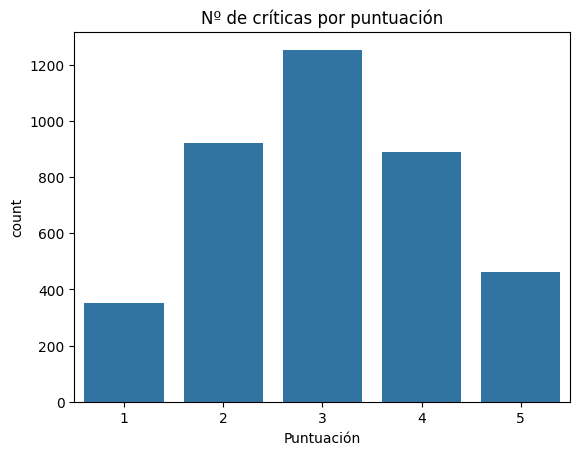

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

movie_reviews_df = pd.read_csv(datos_basedir+ "spanish_movie_reviews.csv",delimiter=',',encoding='utf-8')
movie_reviews_df.dropna(inplace=True)
print(movie_reviews_df.info())

sns.countplot(x=movie_reviews_df.stars)
plt.xlabel('Puntuación')
plt.title('Nº de críticas por puntuación')

movie_reviews_df.head()

Si queremos procesar textos de la web, podemos hacer uso de [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/), que nos facilita el parseo y extracción de los contenedores de textos en los que estemos interesados. Por ejemplo, si queremos extraer el texto de un artículo de Wikipedia, podríamos hacerlo así:

In [ ]:
import requests
from bs4 import BeautifulSoup

# URL de la página de la que quieres extraer el texto
url = 'https://es.wikipedia.org/wiki/Procesamiento_de_lenguajes_naturales'

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Para buscar un div por su ID
div_con_id = soup.find('div', id='mw-content-text')
texto_de_div_con_id = div_con_id.get_text() if div_con_id else 'Div no encontrado'
print(texto_de_div_con_id)

Div no encontrado


Es posible que necesitemos hacer este proceso no para una única página web, sino para un conjunto no conocido a priori de páginas. Para ello, se suelen utilizar los conocidos como scrappers o crawlers (por ejemplo, el mismo BeautifulSoup, o el más potente [Scrapy](https://scrapy.org/)), que nos permiten definir una serie de reglas de navegación para ir accediendo a distintas páginas a partir de una o varias iniciales. Por otra parte, si necesitamos obtener textos de redes sociales, lo  más habitual es utilizar alguna API que permita el acceso programático a la misma.

Tanto el uso de scrappers como el de APIs de redes sociales quedarán al margen del contenido de la asignatura (aunque pueden ser abordados en el proyecto entregable).

## 2. Procesamiento de textos con spaCy

En nuestra asignatura no abordaremos la implementación de algoritmos que resuelvan estas tareas, sino que aprenderemos a usar herramientas que las llevan a cabo, y veremos la utilidad que entrañan y algunas de sus posibles aplicaciones. Existen muchas librerías orientadas al procesamiento del lenguaje que incorporan soluciones a las tareas anteriores. Nosotros usaremos una relativamente reciente, con un gran acabado y eficiencia, llamada **spaCy**.



Una ventaja del uso de spaCy es que, además de resolver las tareas básicas de NLP enumeradas antes, tenemos disponibles modelos preentrenados para las principales lenguas, incluido el español. Esto no siempre es así: otras herramientas precisan disponer de grandes corpus de textos anotados convenientemente para llevar a cabo un proceso de entrenamiento y generación de los modelos necesarios. Aunque esto también se puede hacer con Spacy, disponemos de modelos preentrenados con bastante calidad con los que podemos empezar a funcionar desde el primer minuto. Puedes ver los modelos disponibles [aquí](https://spacy.io/usage/models).

Los ficheros que se descargan empaquetan los modelos necesarios para varias tareas.

In [ ]:
import spacy

print("Cargando modelo...")
nlp = spacy.load('es_core_news_lg')

Cargando modelo...


La función de carga anterior nos devuelve una función de *pipeline*. Esto significa que el procesamiento de un texto determinado es tan simple como invocar a esa función pasándole el texto, lo que desencadenará la ejecución de una serie de analizadores secuencialmente (tokenizer, sentence splitter, POS tagging,...).

In [ ]:
print("Procesando con Spacy el primer review del corpus de críticas de cine...")
doc = nlp(movie_reviews_df["review"][0])
print("Hecho.")

Procesando con Spacy el primer review del corpus de críticas de cine...
Hecho.


También podemos procesar un conjunto de textos de una sola vez. Esto tiene la ventaja de que internamente algunos de los componentes de los modelos son más eficientes cuando trabajan con paquetes de textos, en lugar de con los textos de uno en uno.

In [ ]:
print("Procesando con Spacy todo el dataset...")
docs = list(
    tqdm(     # Decoramos con tqdm para ver barra de progreso
        nlp.pipe(movie_reviews_df["review"], n_process=1),
        total=len(movie_reviews_df)
        )
    )
print("Hecho.")
print("Se han obtenido", len(docs), "documentos.")

Procesando con Spacy todo el dataset...


  0%|          | 0/3877 [00:00<?, ?it/s]

Hecho.
Se han obtenido 3877 documentos.


---
### Oraciones y tokens

En los siguientes ejemplos de código se muestra cómo acceder a la información obtenida tras el procesamiento del texto. Usaremos el primero de los textos procesados:

In [ ]:
# Recorre frases, atributo sents
for i, sent in enumerate(docs[0].sents):
  print(f"Frase {i+1}: ",sent)

Frase 1:  Cada vez me gusta menos el cine de masas .
Frase 2:  Las peliculas que ven todo el mundo me parecen cada vez mas coñazo y mas insufribles .
Frase 3:  No se porqué pero siempre el prota es tonto de el culo y tiene suerte , y a el final de la peli , cuando ha logrado vencer a el mal , se convierte en listo , y las chorradas que hacia a el comienzo de la pelicula se esfuman como por arte de magia .
Frase 4:  Se vuelve maduro e inteligente .
Frase 5:  Esta peli de Spielberg es mas de lo mismo , huir y huir y que no le den ni un solo tiro .
Frase 6:  Además el cabron ha metido a un par de actores que es como para echar les de comer aparte .
Frase 7:  La niña , una vieja metida en el cuerpo de una niña , porque solo hay que ver le hablar ( en version original claro ) para darse cuenta que estamos ante uno de los grandes freaks de el cine .
Frase 8:  Se creeran que hace gracia la nena cuando habla igual que su puta madre , pero a mi me causa pavor .
Frase 9:  Ver a una cria que habl

In [ ]:
from itertools import islice # para recorrer los n primeros elementos de un iterador

# Recorre palabras (tokens)
for tok in islice(docs[0], 20):
    print(tok)
print("...")

Cada
vez
me
gusta
menos
el
cine
de
masas
.
Las
peliculas
que
ven
todo
el
mundo
me
parecen
cada
...


In [ ]:
# Las frases son vistas del documento (ofrecen la misma interfaz)
for i, sent in enumerate(islice(docs[0].sents, 5)):
    print("Frase", i+1)
    for tok in islice(sent, 5):
        print("\t", tok)
    print("\t ...")
print("...")

Frase 1
	 Cada
	 vez
	 me
	 gusta
	 menos
	 ...
Frase 2
	 Las
	 peliculas
	 que
	 ven
	 todo
	 ...
Frase 3
	 No
	 se
	 porqué
	 pero
	 siempre
	 ...
Frase 4
	 Se
	 vuelve
	 maduro
	 e
	 inteligente
	 ...
Frase 5
	 Esta
	 peli
	 de
	 Spielberg
	 es
	 ...
...


In [ ]:
# Los tokens están etiquetados con información morfosintáctica
print("{:15} | {:15} | {:6}".format("Palabra", "Lema", "POS"))
print("------------------------------------------------")
for tok in islice(docs[0], 40):
    # Algunos campos de los tokens están representados por índices o constantes
    # para reducir el empleo de memoria. Si accedemos a dichos campos añadiendo la
    # barra baja, obtenemos la cadena correspondiente.
    print("{:15} | {:15} | {:6}".format(tok.text, tok.lemma_, tok.pos_))

Palabra         | Lema            | POS   
------------------------------------------------
Cada            | cada            | DET   
vez             | vez             | NOUN  
me              | yo              | PRON  
gusta           | gustar          | VERB  
menos           | menos           | ADV   
el              | el              | DET   
cine            | cine            | NOUN  
de              | de              | ADP   
masas           | masa            | NOUN  
.               | .               | PUNCT 
Las             | el              | DET   
peliculas       | pelicula        | NOUN  
que             | que             | PRON  
ven             | ver             | VERB  
todo            | todo            | DET   
el              | el              | DET   
mundo           | mundo           | NOUN  
me              | yo              | PRON  
parecen         | parecer         | VERB  
cada            | cada            | DET   
vez             | vez             | NOUN  
mas  

Saquemos una lista de las distintas etiquetas [POS](https://universaldependencies.org/u/pos/) utilizadas por el modelo, y una lista de ejemplos de cada una. Intenta entender a qué categoría se refiere cada etiqueta (al menos las más comunes: nombre, adjetivo, verbo, ...).

In [ ]:
# Mostrar un listado de las distintas etiquetas POS y algunos ejemplos de cada una:
from collections import defaultdict

pos_ejemplos = defaultdict(set)

for doc in docs:
  for tok in doc:
      pos_ejemplos[tok.pos_].add(tok.text)

for pos, ejemplos in sorted(pos_ejemplos.items()):
    print(pos+":\t", ', '.join(sorted(ejemplos)[:10]),"...")

ADJ:	 10.Sólo, 1ª, 2001.Acierto, 2007.Es, 2ª, 3er, 3ª, 4ª, 5ª, 6ª ...
ADP:	 A, ANDREW, Ante, Bajo, Calculen, Con, Contra, Cy, DE, DESDE ...
ADV:	 '', 1-muy, ANTES, Abajo, Absolutamente, Acaso, Aceptable, Acerca, Acertadamente, Acojonante ...
AUX:	 #, '', AMOS, ANDREWS, Acertando, Basta, CIRCONIO, Cabría, Comencemos, Concisa ...
CCONJ:	 Asi, AtenciónPara, C.S.I., E, Hyung-rae, I, Mas, Mientras, My, NATALIE ...
DET:	 1.931.Su, A, Alguna, Algunas, Algunos, Algún, Always, Aquel, Aquella, Aquellas ...
INTJ:	 Absurdo, Adivina, Adiós, Afín, Agur, Ah, Aleluya, Asi, Ay, Basta ...
NOUN:	 $, &, ', *, /, 1, 1.85, 1.982, 1.999, 10.30 ...
NUM:	 $, -144, .300, /, 0, 0.5, 00, 00.15, 000, 007 ...
PART:	 NO, No, no, te ...
PRON:	 Algo, Alguien, Alguién, Alguna, Algunas, Alguno, Algunos, Aquel, Aquella, Aquello ...
PROPN:	 !, ", #, $, &, ', '', ), *, + ...
PUNCT:	 !, ", #, ', '', (, ), *, ,, - ...
SCONJ:	 Aunque, CUANDO, Como, Cuando, Cuanto, Mientras, PLANET, Porque, Pues, QT ...
SPACE:	       ,  ,    .


Usando las etiquetas POS podemos fácilmente seleccionar determinado tipo de palabras del texto.

---
### Búsqueda de patrones con Matcher

Filtrando las palabras de las críticas de cine etiquetadas como nombre propio podemos encontrar nombres de directores, actores, personajes de ficción, lugares... Pero es común que dichas menciones estén formadas por más de una palabra. ¿Podríamos buscar entidades a partir de secuencias de palabras etiquetadas como nombre propio?

Para hacerlo, podemos utilizar Matcher, otra herramienta proporcionada por spaCy que nos permite buscar secuencias de tokens que concuerden con un patrón determinado:

In [ ]:
# Obtener secuencias de dos o tres palabras consecutivas etiquetadas como PROPN
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)
matcher.add("Dos o tres PROPN consecutivos", [
      [{'POS': 'PROPN'}, {'POS': 'PROPN'}],
      [{'POS': 'PROPN'}, {'POS': 'PROPN'}, {'POS': 'PROPN'}]
    ])

# Para cada coincidencia encontrada por matcher, obtenemos
# una terna match_id, start, end. Con estos dos últimos valores
# podemos recuperar desde el documento los tokens correspondientes
# a la coincidencia.
contador = Counter(str(doc[match[1]:match[2]])
                  for doc in docs
                   for match in matcher(doc))

print("{:>25} | {:>10}".format("Nombre","Frecuencia"))
print("__________________________________________")
for entidad, frecuencia in contador.most_common(100):
    print("{:>25} | {:>10}".format(entidad, frecuencia))

                   Nombre | Frecuencia
__________________________________________
                  & ldquo |       1302
                  & rdquo |       1170
           Estados Unidos |        218
                 & hellip |        156
                  & rsquo |        144
               Nueva York |        133
              Woody Allen |        130
             Harry Potter |        113
                     P. D |        103
                  & ndash |        103
                 Iwo Jima |         99
               James Bond |         82
               Tim Burton |         78
           Guerra Mundial |         74
           Clint Eastwood |         73
             Bruce Willis |         71
               Will Smith |         71
             Nicolas Cage |         67
            Michael Caine |         66
            Planet Terror |         62
             Hugh Jackman |         59
               Matt Damon |         57
             Ridley Scott |         56
                Star 

Puedes ver las posibilidades que ofrece Matcher en esta guía: https://spacy.io/usage/rule-based-matching.

Para hacer patrones más complejos y poderlos depurar antes de incluirlos en tu código, puedes utilizar esta herramienta online: https://explosion.ai/demos/matcher.

### **☞ Ejercicio entregable**: Obtener secuencias de dos o más nombres propios

Repite el proceso anterior, pero modificando las reglas de Matcher para que se obtengan todas las apariciones de 2 o más nombres propios consecutivos.

In [ ]:
# TODO: Obtener secuencias de dos o más nombres propios consecutivos
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

# Patron - un nombre propio seguido de uno o más nombres propios. El operador + para 1 o más veces
pattern = [{"POS": "PROPN"}, {"POS": "PROPN", "OP": "+"}]

matcher.add("DOS_O_MAS_PROPN", [pattern])

# Conteo sobre todos los documentos - docs
contador_ejercicio = Counter(str(doc[match[1]:match[2]])
                             for doc in docs
                             for match in matcher(doc))

print("{:>25} | {:>10}".format("Nombre (2 o más)", "Frecuencia"))
print("_" * 40)
for entidad, frecuencia in contador_ejercicio.most_common(50):
    print("{:>25} | {:>10}".format(entidad, frecuencia))

         Nombre (2 o más) | Frecuencia
________________________________________
                  & ldquo |       1302
                  & rdquo |       1170
           Estados Unidos |        218
                 & hellip |        156
                  & rsquo |        144
               Nueva York |        133
              Woody Allen |        130
             Harry Potter |        113
                     P. D |        103
                  & ndash |        103
                 Iwo Jima |         99
               James Bond |         82
               Tim Burton |         78
           Guerra Mundial |         74
           Clint Eastwood |         73
             Bruce Willis |         71
               Will Smith |         71
             Nicolas Cage |         67
            Michael Caine |         66
            Planet Terror |         62
             Hugh Jackman |         59
               Matt Damon |         57
             Ridley Scott |         56
                Star Wa

---
### Reconocimiento de entidades nombradas
Una forma mejor de hacer lo anterior es usar el reconocimiento de entidades nombradas (NER, por sus siglas en inglés: Named-Entity Recognition). De esta forma, las entidades encontradas serán conjuntos de palabras que "*funcionan como*" nombres propios, pero que no necesariamente son todas ellas nombres propios; por ejemplo, "El Código da Vinci", que es el título de una película, incluye la palabra "El", que no es un nombre propio, pero que forma parte del nombre de la película.

Por otra parte, la herramienta NER también clasifica las entidades encontradas por tipo. Observa la información contenida en los atributos de cada una de las entidades que obtenemos (text, start_char, end_char, ...):

In [ ]:
# Reconocimiento de entidades

import textwrap # Para formatear el texto mostrado a un ancho determinado

print("Texto usado para la prueba:\n", textwrap.fill(str(docs[100]), 80), "\n")
print("{:<50} {:>5} {:>5} {:>5} {:>10}".format("Entidad", "start", "end", "TIPO", "root"))
print("________________________________________________________________________________")
for ent in islice(docs[100].ents,5):
    print("{:<50} {:>5} {:>5} {:>5} {:>10}".format(ent.text, ent.start_char, ent.end_char, ent.label_, ent.root.text))

Texto usado para la prueba:
 En el cartel de la película , parece que Truman esté preparado en la barrera
para que le tiren una falta . Ahí , agarrando se la zona urogenital con esa mano
floja y amanerada que sujeta un eterno cigarro . Por cierto , qué sensual era el
tabaco antes , ¿ no ? La película trata sobre el periodo de tiempo en la vida de
Truman Capote , que invirtió en escribir su obra maestra " A sangre fría " . Un
día , Truman lee en un periódico un horrible asesinato acometido en un pequeño
pueblito . Se marcha a el pueblo a escribir un artículo , pero tras conocer a
los supuestos asesinos , Capote se involucra excesivamente en lo que él ve como
un tremendo filón literario . La verdad que la película me ha defraudado
bastante , dado que me esperaba algo más emocionante , y la vida que nos
muestran de Capote es muy aburrida . Nos enseñan la obsesión que llegó a
alcanzar por esta historia , y nos perfilan como debió ser este escritor . Pero
la verdad que no llega a enganchar 

---
Saquemos una tabla con el número de entidades encontradas en el texto de cada tipo, y mostremos las 30 entidades más frecuentes de cada tipo:

In [ ]:
# Sacar una lista con el número de entidades por tipo
contador = Counter(ent.label_
                   for doc in docs
                   for ent in doc.ents)
print("{:>5} | {:>10}".format("Tipo","Frecuencia"))
print("_____________________________________")
for tipo, frecuencia in contador.items():
    print("{:>5} | {:>10}".format(tipo, frecuencia))

 Tipo | Frecuencia
_____________________________________
 MISC |      51327
  ORG |       3303
  PER |      37440
  LOC |       8487


In [ ]:
# Sacar listas con las 30 entidades más frecuentes de cada tipo
entidades_por_tipo = {}
for tipo in ["PER", "LOC", "ORG", "MISC"]:
    entidades_por_tipo[tipo] = Counter(ent.text
                                       for doc in docs
                                       for ent in doc.ents
                                       if ent.label_ == tipo)
d = {tipo: entidades.most_common(30)
     for tipo, entidades in entidades_por_tipo.items()}
df = pd.DataFrame(data=d)
df

,PER,LOC,ORG,MISC
0,"(Spielberg, 190)","(España, 354)","(Pixar, 96)","(La película, 748)"
1,"(Tarantino, 164)","(Hollywood, 315)","(Historia, 66)","(Sin embargo, 277)"
2,"(Bond, 162)","(USA, 116)","(Más, 43)","(Resumiendo, 240)"
3,"(Hitchcock, 157)","(Londres, 116)","(Iglesia, 37)","(Ahora, 216)"
4,"(Eastwood, 154)","(Nueva York, 115)","(CIA, 36)","(La historia, 191)"
5,"(Woody Allen, 129)","(Europa, 98)","(FBI, 35)","(El guión, 148)"
6,"(Scorsese, 109)","(América, 89)","(United 93, 33)","(Bueno, 131)"
7,"(Superman, 90)","(Madrid, 87)","(Disney, 28)","(Oscar, 126)"
8,"(Stallone, 90)","(Francia, 78)","(Vale, 26)","(Alatriste, 120)"
9,"(Allen, 87)","(París, 68)","(Marvel, 26)","(La verdad, 104)"


Lee las listas con detenimiento y trata de encontrar errores. ¿Qué tipo de entidades acumula más errores?

### **☞ Ejercicio entregable**: Temas del día en El País

Buscar todas las entidades (y sus frecuencias) que aparecen nombradas en los textos de las noticias enlazadas en la página principal de El País. No utilizar las entidades de tipo MISC.

Inspeccione la página principal de la web para encontrar algún elemento que le permita recopilar todos los enlaces a las noticias. Luego, para cada uno de estos enlaces, extraiga el texto del artículo principal, de forma similar a como hicimos en el ejercicio anterior, y procéselo con spaCy para detectar las entidades nombradas.

  0%|          | 0/3 [00:00<?, ?it/s]

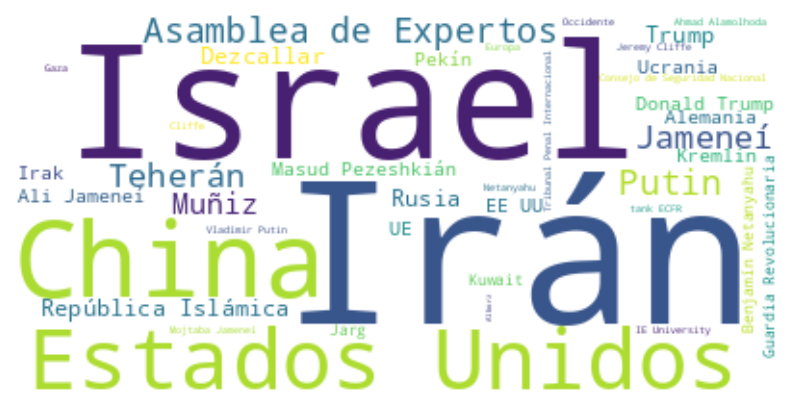

In [ ]:
import requests
from bs4 import BeautifulSoup

def extrae_re(url, nlp):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')

    div_con_id = soup.find('div', class_='a_c clearfix')
    texto = div_con_id.get_text() if div_con_id else ''

    if texto:
        doc = nlp(texto)
        return [ent.text for ent in doc.ents if ent.label_ != "MISC"]
    else:
        return []

# Realiza la petición a la página web
response = requests.get("https://elpais.com/")

1# Crea una instancia de BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

# Encuentra todos los elementos h2 con la clase 'c_t'
h2_elements = soup.find_all('h2', class_='c_t')

# Extrae las URLs de los enlaces dentro de esos h2
urls = [link['href'] for h2 in h2_elements for link in h2.find_all('a')]

contador = Counter()
for url in tqdm(urls):
    contador.update(extrae_re(url, nlp))

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generar la nube de palabras
wordcloud = WordCloud(background_color ='white').generate_from_frequencies(contador)

# Visualizar la nube de palabras con Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # No mostrar los ejes para una visualización más limpia
plt.show()


---
### Análisis sintáctico
Veamos ahora dos tipos de análisis realizados por el pipeline de Spacy de caracter sintáctico (es decir, relacionados con las relaciones sintácticas entre las palabras que componen las oraciones). Podemos iterar sobre los sintagmas nominales encontrados en el texto (este tipo de análisis se denomina **chunking**, aunque en Spacy sólo tenemos **noun chunking**):

In [ ]:
# Sintagmas nominales

print("Texto usado para la prueba:\n", textwrap.fill(str(docs[0])[:300]+"...", 80), "\n")
print("{:15} | {:10}".format("Sintagma", "Núcleo"))
print("____________________________")
for chunk in islice(docs[0].noun_chunks,20):
      print("{:15} | {:10}".format(chunk.text, chunk.root.text))


Texto usado para la prueba:
 Cada vez me gusta menos el cine de masas . Las peliculas que ven todo el mundo
me parecen cada vez mas coñazo y mas insufribles . No se porqué pero siempre el
prota es tonto de el culo y tiene suerte , y a el final de la peli , cuando ha
logrado vencer a el mal , se convierte en listo , y las chorra... 

Sintagma        | Núcleo    
____________________________
Cada vez        | vez       
el cine         | cine      
masas           | masas     
Las peliculas   | peliculas 
que             | que       
todo el mundo   | mundo     
cada vez        | vez       
el prota        | prota     
el culo         | culo      
suerte          | suerte    
, y a el final  | final     
la peli         | peli      
el mal          | mal       
, y las chorradas | chorradas 
que             | que       
a el comienzo   | comienzo  
la pelicula     | pelicula  
como por arte   | arte      
magia           | magia     
Esta peli       | peli      


También podemos acceder a todas las dependencias sintácticas encontradas entre las palabras de las oraciones.

In [ ]:
# Árbol de dependencias sintácticas (dependency parsing)

frase = next(islice(docs[100].sents, 4, None)) # Accedemos a la frase número 4 del review 100
print(frase,"\n");
print("{:10} | {:8} | {:12} | {:20} | {}".format("Palabra", "DEP", "Padre (head)", "Hijos (children)", "Subárbol (subtree)"))
print("___________________________________________________________________________________________")
for token in frase:
    print("{:10} | {:8} | {:12} | {:20} | {}".format(token.text, token.dep_, token.head.text,
          ','.join([child.text for child in token.children]), ' '.join(t.text for t in token.subtree)))

Un día , Truman lee en un periódico un horrible asesinato acometido en un pequeño pueblito . 

Palabra    | DEP      | Padre (head) | Hijos (children)     | Subárbol (subtree)
___________________________________________________________________________________________
Un         | det      | día          |                      | Un
día        | obl      | lee          | Un,,                 | Un día ,
,          | punct    | día          |                      | ,
Truman     | nsubj    | lee          |                      | Truman
lee        | ROOT     | lee          | día,Truman,periódico,asesinato,. | Un día , Truman lee en un periódico un horrible asesinato acometido en un pequeño pueblito .
en         | case     | periódico    |                      | en
un         | det      | periódico    |                      | un
periódico  | obl      | lee          | en,un                | en un periódico
un         | det      | asesinato    |                      | un
horrible   | amod     |

In [ ]:
# Representación del árbol
from spacy import displacy
displacy.render(frase, style='dep', jupyter=True)

Como puedes observar, las dependencias sintácticas forman un árbol entre las palabras. El árbol de dependencias sintácticas es una versión simplificada del clásico árbol sintáctico. En un análisis sintáctico completo, las palabras se agrupan en sintagmas y otras estructuras de frase, que a su vez se van agrupando hasta llegar a la raíz del árbol, que es la oración. Sin embargo, en el análisis de dependencias, las relaciones se establecen únicamente entre las palabras.

Con el paso de los años, se ha observado que este tipo de análisis sintáctico (el de dependencias) es más sencillo y útil para la mayoría de los problemas de tratamiento de textos.

## **☞ Ejercicio entregable**: Búsqueda de adjetivos relacionados con entidades

Queremos obtener listas de los adjetivos que aparecen en los textos de los reviews relacionados con las entidades con nombre de tipo Persona.

Intenta localizar sólo los adjetivos que cuelgan directamente de algunos de los tokens que conforman cada una de las entidades de tipo Persona de los reviews. Dada una entidad, hay que buscar entre los hijos que cuelgan directamente de cada uno de los tokens de dicha entidad, con una relación de dependencia de tipo ``amod`` o ``appos``.

La función que se pide debe devolver un diccionario en el que las claves serán las entidades de tipo persona (en formato cadena de texto), y los valores asociados serán listas de los adjetivos encontrados (también en formato cadena de texto).

In [ ]:
def extrae_adjetivos_entidades(docs):
    # Usamos defaultdict para que la variable siempre sea un diccionario, nunca None
    propiedades_dict = defaultdict(list)

    for doc in docs:
        for ent in doc.ents:
            # Filtramos por tipos de entidad comunes para limpiar ruido
            if ent.label_ in ["PER", "ORG", "LOC"]:
                nombre = ent.text
                root = ent.root

                # Buscamos adjetivos que sean hijos directos del núcleo de la entidad
                for hijo in root.children:
                    if hijo.pos_ == "ADJ":
                        propiedades_dict[nombre].append(hijo.lemma_.lower())

                # Buscamos adjetivos cuando la entidad es sujeto (ej: "Spielberg es grande")
                if root.dep_ in ("nsubj", "nsubj:pass") and root.head.pos_ in ("AUX", "VERB"):
                    for hermano in root.head.children:
                        if hermano.pos_ == "ADJ":
                            propiedades_dict[nombre].append(hermano.lemma_.lower())
    return propiedades_dict

propiedades = extrae_adjetivos_entidades(docs)

# Mostramos los adjetivos para Emily Mortimer
print("Emily Mortimer:")
for adjetivo in propiedades["Emily Mortimer"]:
  print("\t", adjetivo)
print("================================")

# Mostramos las 10 entidades con más calificativos
print("\nLas 10 entidades con más calificativos distintos:")
for entidad, _ in sorted(propiedades.items(), key = lambda t:len(set(t[1])), reverse=True)[:10]:
    if propiedades[entidad]:
        print("{}:".format(entidad))
        for propiedad in set(propiedades[entidad]):
            print("\t{}".format(propiedad))

Emily Mortimer:
	 bello

Las 10 entidades con más calificativos distintos:
Londres:
	marginal
	victoriano
	sumido
	solitario
	similar
	gris
	segundo
	reconocible
	conmovedor
	lleno
	aséptico
	post-epidemia
	futurible
	moderno
	suburbial
	natal
	irreconocible
	viejo
	extraño
	triste
	decimonónico
	multicultural
	desértico
	actual
	sectorizado
España:
	gran
	campechano
	posterior
	alimentado
	directo
	detenido
	gris
	negro
	cochambroso
	oficial
	diferente
	claro
	moderno
	urbano
	hondo
	profundo
	enganchado
	mediterráneo
	triste
	rural
	devorado
	sesentero
	ajeno
Bond:
	carismático
	gran
	realista
	duro
	nuevo
	próximo
	mejor
	indestructible
	misógino
	buen
	etílico
	joven
	encarnado
	popular
	novato
	rubio
	último
	clásico
	límpido
	perfecto
	terrenal
	humano
Hollywood:
	utilitarista
	atípico
	comercial
	esplendoroso
	clásico
	mismísimo
	enjundioso
	propio
	oscuro
	viejo
	pedrusco
	escorado
	todopoderoso
	efervescente
	actual
	dorado
	veterano
	facturado
Tarantino:
	tarantino
	dirigido


In [ ]:
# Ver las 20 personas más mencionadas en el corpus
print(df["PER"].head(20))
# Ver las 20 localizaciones más mencionadas en el corpus
print(df["LOC"].head(10))

0         (Spielberg, 190)
1         (Tarantino, 164)
2              (Bond, 162)
3         (Hitchcock, 157)
4          (Eastwood, 154)
5       (Woody Allen, 129)
6          (Scorsese, 109)
7           (Superman, 90)
8           (Stallone, 90)
9              (Allen, 87)
10             (Oscar, 87)
11             (Lynch, 85)
12        (James Bond, 79)
13           (Kubrick, 79)
14        (Tim Burton, 78)
15            (Disney, 77)
16           (Besitos, 77)
17         (Spiderman, 76)
18    (Clint Eastwood, 72)
19      (Bruce Willis, 71)
Name: PER, dtype: object
0        (España, 354)
1     (Hollywood, 315)
2           (USA, 116)
3       (Londres, 116)
4    (Nueva York, 115)
5         (Europa, 98)
6        (América, 89)
7         (Madrid, 87)
8        (Francia, 78)
9          (París, 68)
Name: LOC, dtype: object


In [ ]:
# Implementa aquí tu función
# BUSCAR adjetivos relacionados con entidades

def buscar_adjetivos_entidad(docs, nombre_entidad):
    adjetivos = []

    for doc in docs:
        for ent in doc.ents:
            # Comprobamos si la entidad es la que buscamos (ignorando mayúsculas/minúsculas)
            if nombre_entidad.lower() in ent.text.lower():
                root = ent.root

                # Buscamos en sus hijos directos si hay adjetivos
                for hijo in root.children:
                    if hijo.pos_ == "ADJ":
                        adjetivos.append(hijo.lemma_.lower())

                # Comprobar si root es sujeto de un verbo copulativo (ser/estar)
                # Ej: "Spielberg es MARAVILLOSO"
                if root.dep_ in ("nsubj", "nsubj:pass") and root.head.pos_ in ("AUX", "VERB"):
                    for hermano in root.head.children:
                        if hermano.pos_ == "ADJ":
                            adjetivos.append(hermano.lemma_.lower())

    return Counter(adjetivos)

# Ejemplo de uso (cambiar la palabra ejemplo)
entidad_a_buscar = "Francia"
resultados = buscar_adjetivos_entidad(docs, entidad_a_buscar)

print(f"Adjetivos asociados a '{entidad_a_buscar}':")
print("-" * 40)
for adj, frec in resultados.most_common(20):
    print(f"{adj:<15} | {frec} apariciones")


# Ejemplo de uso (cambiar la palabra ejemplo)
entidad_a_buscar = "Cruise"
resultados = buscar_adjetivos_entidad(docs, entidad_a_buscar)

print(f"Adjetivos asociados a '{entidad_a_buscar}':")
print("-" * 40)
for adj, frec in resultados.most_common(20):
    print(f"{adj:<15} | {frec} apariciones")

# Ejemplo de uso (cambiar la palabra ejemplo)
entidad_a_buscar = "España"
resultados = buscar_adjetivos_entidad(docs, entidad_a_buscar)

print(f"Adjetivos asociados a '{entidad_a_buscar}':")
print("-" * 40)
for adj, frec in resultados.most_common(20):
    print(f"{adj:<15} | {frec} apariciones")

Adjetivos asociados a 'Francia':
----------------------------------------
incluido        | 1 apariciones
vecino          | 1 apariciones
pleno           | 1 apariciones
profundo        | 1 apariciones
francés         | 1 apariciones
Adjetivos asociados a 'Cruise':
----------------------------------------
mejor           | 3 apariciones
creíble         | 1 apariciones
último          | 1 apariciones
incluido        | 1 apariciones
exprimido       | 1 apariciones
Adjetivos asociados a 'España':
----------------------------------------
profundo        | 8 apariciones
rural           | 5 apariciones
grande          | 2 apariciones
gran            | 2 apariciones
directo         | 2 apariciones
gris            | 1 apariciones
urbano          | 1 apariciones
cochambroso     | 1 apariciones
devorado        | 1 apariciones
posterior       | 1 apariciones
mediterráneo    | 1 apariciones
diferente       | 1 apariciones
moderno         | 1 apariciones
enganchado      | 1 apariciones
reciente    

---

## **☞ Ejercicio entregable**: Cálculo de la polaridad de las opiniones sobre entidades

Ahora que tenemos adjetivos que se refieren a las entidades, hagamos un cálculo de opinión basado en la polaridad de dichos adjetivos. Queremos responder a la pregunta: ¿qué tipo de opiniones contienen nuestros reviews de cine sobre las personas que se nombran?

Vamos a cargar un recurso llamado [ML-Senticon](https://github.com/ITALIC-US/ML-Senticon) que contiene estimaciones de polaridad a nivel de palabras, y usaremos esas estimaciones para calcular una media de la "positividad" o "negatividad" de las opiniones expresadas.

(Tenga en cuenta que es un acercamiento muy naif, más adelante probaremos con técnicos más potentes)

In [ ]:
# ML-Senticon
import xml.etree.ElementTree as ET
from spacy.symbols import ADJ, ADV, NOUN, VERB

def carga_ml_senticon(ruta=datos_basedir + 'senticon.es.xml', niveles = {1,2,3,4,5,6,7,8}):
    senticon = {}
    tree = ET.parse(ruta)
    root = tree.getroot()
    for level in root:
        if int(level.attrib['level']) in niveles:
            for polarity in level:
                for word in polarity:
                    palabra_pos = word.text.strip() + "_" + word.attrib['pos']
                    polaridad = float(word.attrib['pol'])
                    senticon[palabra_pos] = polaridad
    return senticon

SENTICON = carga_ml_senticon()
print("ML-Senticon: {} entradas cargadas.".format(len(SENTICON)))

print("\nFragmento de las entradas del lexicon:")
for palabra_pos, polaridad in islice(SENTICON.items(),20):
    print("\t",palabra_pos, polaridad)
print("\t ...")

ML-Senticon: 11542 entradas cargadas.

Fragmento de las entradas del lexicon:
	 acertado_a 0.708
	 admirable_a 0.906
	 admiración_n 0.45
	 admirar_v 0.75
	 afectivo_a 0.375
	 afecto_n 0.321
	 afectuoso_a 0.563
	 afición_n 0.5
	 afortunado_a 0.813
	 agradable_a 0.75
	 agradecido_a 0.5
	 alegrar_v 0.458
	 alegre_a 0.661
	 alentador_a 0.594
	 alentar_v 0.275
	 amable_a 0.688
	 amar_v 1.0
	 amistoso_a 0.708
	 amor_n 0.278
	 animado_a 0.494
	 ...


Calcula **la suma de las polaridades de los adjetivos de cada entidad**, y muestra una lista con las 20 con peor puntuación y las 20 con mejor puntuación.

In [ ]:
# TODO: Hazlo una vez resuelto el ejercicio de extracción de adjetivos
from collections import defaultdict

# 1. Suma de polaridades por entidad
entidades_suma_pol = defaultdict(float)

for nombre, adjetivos in propiedades.items():
    suma_actual = 0.0
    for adj in adjetivos:
        # SENTICON usa '_a' para marcar adjetivos
        clave_senticon = adj + "_a"

        if clave_senticon in SENTICON:
            suma_actual += SENTICON[clave_senticon]

    entidades_suma_pol[nombre] = suma_actual

# 2. Convertimos a una lista de tuplas para poder ordenar
ranking = sorted(entidades_suma_pol.items(), key=lambda x: x[1], reverse=True)

# 3. Resultados
print("=== LAS 20 ENTIDADES CON MEJOR PUNTUACIÓN (SUMA) ===")
for entidad, suma in ranking[:20]:
    print(f"{entidad:<30} | {suma:>6.2f}")

print("\n")

print("\n=== LAS 20 ENTIDADES CON PEOR PUNTUACIÓN (SUMA) ===")
# Para las peores, cogemos los últimos 20 y les damos la vuelta
for entidad, suma in reversed(ranking[-20:]):
    print(f"{entidad:<30} | {suma:>6.2f}")

=== LAS 20 ENTIDADES CON MEJOR PUNTUACIÓN (SUMA) ===
América                        |   7.31
Hollywood                      |   5.11
Bond                           |   4.88
Banda Sonora                   |   4.83
Tarantino                      |   4.38
Bruce Willis                   |   3.86
James Bond                     |   3.71
Cate Blanchett                 |   3.71
Paul Giamatti                  |   3.69
España                         |   3.59
Tim Burton                     |   3.41
Jamie Foxx                     |   3.35
Brad Bird                      |   3.14
Clive Owen                     |   3.09
Judi Dench                     |   2.98
Daniel Craig                   |   2.88
Gong Li                        |   2.87
Kurt Russell                   |   2.69
Stallone                       |   2.55
Hugh Jackman                   |   2.54



=== LAS 20 ENTIDADES CON PEOR PUNTUACIÓN (SUMA) ===
Nueva York                     |  -2.56
África                         |  -1.61
Segundo     

Haz un análisis crítico de este ejercicio. ¿Qué cosas se te ocurren que se podrían mejorar? ¿Qué fallos, simplificaciones o deficiencias observas en las soluciones planteadas?

1. *Posibilidad de usar el promedio en lugar de la suma:*
Al usar la suma, las entidades que aparecen mucho (por ej "America" o "Hollywood") tienden a acumular puntuaciones más altas. No es que sean mejores sino que se habla más de ellas.
Sería más justo usar la **media aritmética** (dividiendo la suma entre el num. de adjetivos) para que una entidad con una sola opinión muy positiva no "gane" a una con muchas opiniones moderadas.

2. *No se tiene en cuenta el contexto:*
Por ejemplo, si tuvieramos "X no es aburrido", el sistema detecta la palabra aburrido y resta puntos, cuando en realidad se está negando adjetivo negativo, por tanto resultado sería positivo.

3. *Hay adjetivos que dependen del género*. En el cine de miedo, "terrible" o "miedoso" pueden ser cumplidos, pero el diccionario los marca como negativos.

4. *Se tratan igual los adjutivos solos que los que llevan intensificador delante*. Realmente no es lo mismo "bueno" que "super bueno". El sistema trata a todos los adjetivos por igual si están en el diccionario.
*Posible mejora*: Detectar adverbios (como "muy", "poco", "demasiado") que modifiquen la intensidad de la polaridad del adjetivo.